In [26]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh

In [27]:
np.load("data/graspdata_selected/shadow_dexee/mujoco-Black_Decker_CM2035B_12Cup_Thermal_Coffeemaker.npy", allow_pickle=True)
object_mesh = trimesh.load("data/selected_mesh/core-pistol-4648980f23149150edfe35c9179614ca/coacd/decomposed.obj")

In [28]:
# Load and examine the data structure
data = np.load("data/graspdata_selected/shadow_dexee/sem-Hammer-405f308492a6f40d2c3380317c2cc450.npy", allow_pickle=True)
print("Data type:", type(data))
print("Data shape:", data.shape)
print("Data dtype:", data.dtype)

# Examine the first element to understand the structure
print("\nFirst element:")
print("Type of first element:", type(data[0]))
if hasattr(data[0], 'dtype'):
    print("First element dtype:", data[0].dtype)
if hasattr(data[0], 'shape'):
    print("First element shape:", data[0].shape)

# If it's an object array, check if elements are dictionaries
if data.dtype == 'object':
    first_item = data[0]
    if isinstance(first_item, dict):
        print("First element keys:", list(first_item.keys()))

Data type: <class 'numpy.ndarray'>
Data shape: (400,)
Data dtype: object

First element:
Type of first element: <class 'dict'>
First element keys: ['scale', 'qpos', 'qpos_st', 'energy', 'E_fc', 'E_dis', 'E_pen', 'E_spen', 'E_joints']


In [29]:
# Check if scale information is available in the data
print("Checking for scale information:")
first_item = data[0]
if 'scale' in first_item:
    scale_value = first_item['scale']
    print(f"Scale found: {scale_value}")
    print(f"Scale type: {type(scale_value)}")
    
    # Check scale values across all configurations
    scales = [item['scale'] for item in data]
    scales = np.array(scales)
    print(f"Scale statistics:")
    print(f"  Min scale: {scales.min():.6f}")
    print(f"  Max scale: {scales.max():.6f}")
    print(f"  Mean scale: {scales.mean():.6f}")
    print(f"  Unique scales: {len(np.unique(scales))}")
    if len(np.unique(scales)) <= 5:
        print(f"  Scale values: {np.unique(scales)}")
else:
    print("No scale information found in data")
    scales = None

# Object mesh info
print(f"\nOriginal object mesh bounds:")
print(f"  X: [{object_mesh.vertices[:, 0].min():.3f}, {object_mesh.vertices[:, 0].max():.3f}]")
print(f"  Y: [{object_mesh.vertices[:, 1].min():.3f}, {object_mesh.vertices[:, 1].max():.3f}]")
print(f"  Z: [{object_mesh.vertices[:, 2].min():.3f}, {object_mesh.vertices[:, 2].max():.3f}]")

Checking for scale information:
Scale found: 0.20000000298023224
Scale type: <class 'float'>
Scale statistics:
  Min scale: 0.200000
  Max scale: 0.200000
  Mean scale: 0.200000
  Unique scales: 1
  Scale values: [0.2]

Original object mesh bounds:
  X: [-0.135, 0.135]
  Y: [-0.528, 0.530]
  Z: [-0.827, 0.827]


In [30]:
# Extract energy values from the data
energy_values = []
E_fc_values = []
E_dis_values = []
E_pen_values = []
E_spen_values = []
E_joints_values = []

for item in data:
    energy_values.append(item['energy'])
    E_fc_values.append(item['E_fc'])
    E_dis_values.append(item['E_dis'])
    E_pen_values.append(item['E_pen'])
    E_spen_values.append(item['E_spen'])
    E_joints_values.append(item['E_joints'])

# Convert to numpy arrays for easier handling
energy_values = np.array(energy_values)
E_fc_values = np.array(E_fc_values)
E_dis_values = np.array(E_dis_values)
E_pen_values = np.array(E_pen_values)
E_spen_values = np.array(E_spen_values)
E_joints_values = np.array(E_joints_values)

print("Energy statistics:")
print(f"Total energy - min: {energy_values.min():.4f}, max: {energy_values.max():.4f}, mean: {energy_values.mean():.4f}")
print(f"Force closure energy - min: {E_fc_values.min():.4f}, max: {E_fc_values.max():.4f}, mean: {E_fc_values.mean():.4f}")
print(f"Distance energy - min: {E_dis_values.min():.4f}, max: {E_dis_values.max():.4f}, mean: {E_dis_values.mean():.4f}")
print(f"Penetration energy - min: {E_pen_values.min():.4f}, max: {E_pen_values.max():.4f}, mean: {E_pen_values.mean():.4f}")
print(f"Surface penetration energy - min: {E_spen_values.min():.4f}, max: {E_spen_values.max():.4f}, mean: {E_spen_values.mean():.4f}")
print(f"Joints energy - min: {E_joints_values.min():.4f}, max: {E_joints_values.max():.4f}, mean: {E_joints_values.mean():.4f}")

Energy statistics:
Total energy - min: 2.3612, max: 42.6468, mean: 15.4602
Force closure energy - min: 0.0068, max: 16.2990, mean: 5.1104
Distance energy - min: 0.0106, max: 0.2968, mean: 0.0965
Penetration energy - min: 0.0000, max: 0.1035, mean: 0.0035
Surface penetration energy - min: 0.0000, max: 0.0000, mean: 0.0000
Joints energy - min: 0.0000, max: 0.0018, mean: 0.0000


In [31]:
energys = E_fc_values + E_dis_values + E_pen_values + E_spen_values + E_joints_values
whattt = energy_values / energys
energy_values[1] / energys[1] 
 

19.53451862934133

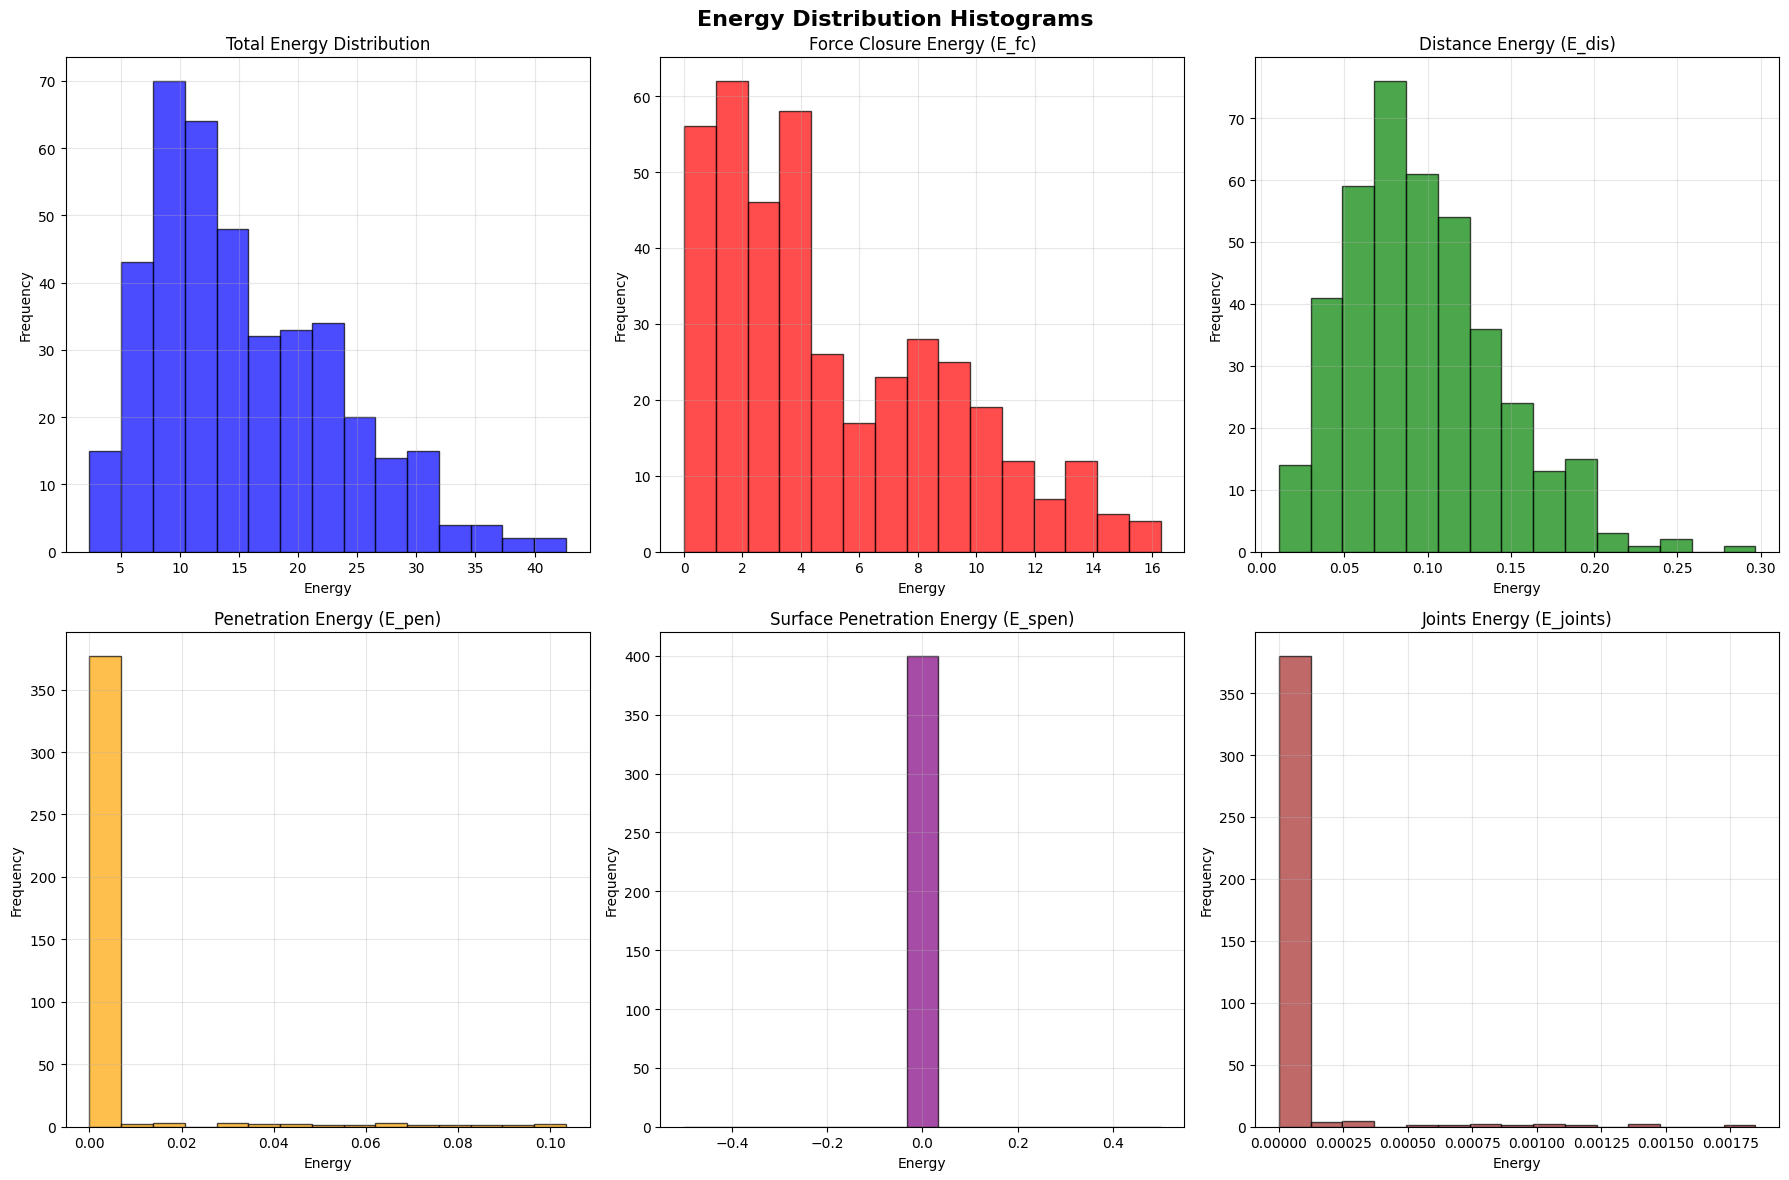

In [32]:
# Create comprehensive histogram plots for energy values
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Energy Distribution Histograms', fontsize=16, fontweight='bold')

# Plot total energy
axes[0, 0].hist(energy_values, bins=15, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('Total Energy Distribution')
axes[0, 0].set_xlabel('Energy')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Plot force closure energy
axes[0, 1].hist(E_fc_values, bins=15, alpha=0.7, color='red', edgecolor='black')
axes[0, 1].set_title('Force Closure Energy (E_fc)')
axes[0, 1].set_xlabel('Energy')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Plot distance energy
axes[0, 2].hist(E_dis_values, bins=15, alpha=0.7, color='green', edgecolor='black')
axes[0, 2].set_title('Distance Energy (E_dis)')
axes[0, 2].set_xlabel('Energy')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].grid(True, alpha=0.3)

# Plot penetration energy
axes[1, 0].hist(E_pen_values, bins=15, alpha=0.7, color='orange', edgecolor='black')
axes[1, 0].set_title('Penetration Energy (E_pen)')
axes[1, 0].set_xlabel('Energy')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# Plot surface penetration energy
axes[1, 1].hist(E_spen_values, bins=15, alpha=0.7, color='purple', edgecolor='black')
axes[1, 1].set_title('Surface Penetration Energy (E_spen)')
axes[1, 1].set_xlabel('Energy')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(True, alpha=0.3)

# Plot joints energy
axes[1, 2].hist(E_joints_values, bins=15, alpha=0.7, color='brown', edgecolor='black')
axes[1, 2].set_title('Joints Energy (E_joints)')
axes[1, 2].set_xlabel('Energy')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

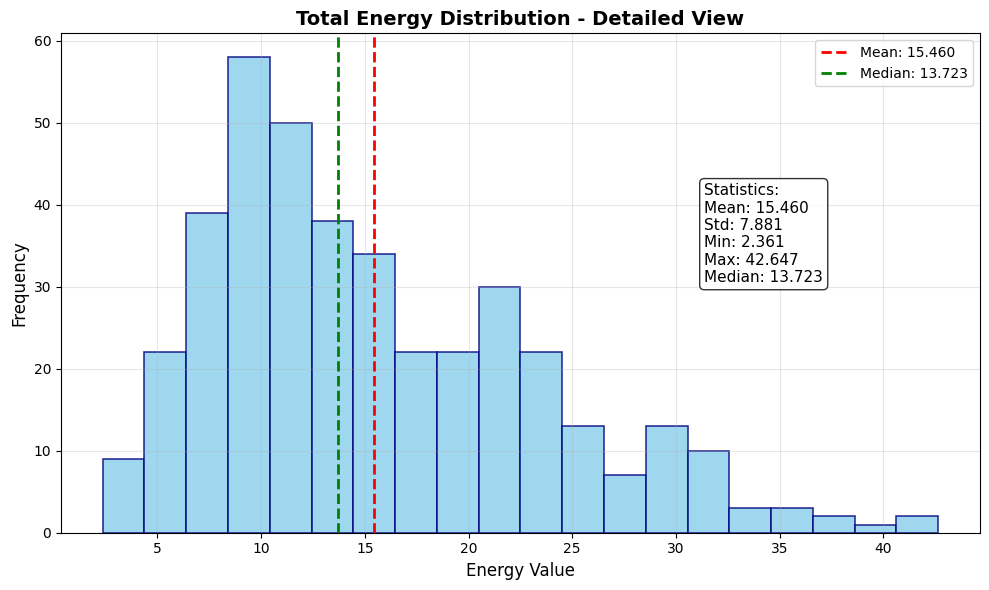

Sample size: 400 grasp configurations


In [33]:
# Create a focused histogram for total energy with additional statistics
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(energy_values, bins=20, alpha=0.8, color='skyblue', 
                           edgecolor='navy', linewidth=1.2)

# Add statistics text
stats_text = f"""Statistics:
Mean: {energy_values.mean():.3f}
Std: {energy_values.std():.3f}
Min: {energy_values.min():.3f}
Max: {energy_values.max():.3f}
Median: {np.median(energy_values):.3f}"""

plt.text(0.7, 0.7, stats_text, transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add mean line
plt.axvline(energy_values.mean(), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {energy_values.mean():.3f}')

# Add median line
plt.axvline(np.median(energy_values), color='green', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(energy_values):.3f}')

plt.title('Total Energy Distribution - Detailed View', fontsize=14, fontweight='bold')
plt.xlabel('Energy Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Print sample size
print(f"Sample size: {len(energy_values)} grasp configurations")

In [34]:
# Examine the qpos_st data structure to find WRJTx, WRJTy, WRJTz indices
print("Examining qpos_st structure:")
first_item = data[0]
if 'qpos_st' in first_item:
    qpos_st = first_item['qpos_st']
    print(f"qpos_st type: {type(qpos_st)}")
    
    if isinstance(qpos_st, dict):
        print(f"qpos_st keys: {list(qpos_st.keys())}")
        # Look for wrist rotation joints
        wrist_keys = [key for key in qpos_st.keys() if 'WRJ' in key or 'wrist' in key.lower()]
        print(f"Wrist-related keys: {wrist_keys}")
        
        # Check specific keys we're looking for
        target_joints = ['WRJTx', 'WRJTy', 'WRJTz']
        found_joints = []
        for joint in target_joints:
            if joint in qpos_st:
                found_joints.append(joint)
                print(f"{joint}: {qpos_st[joint]}")
        
        if not found_joints:
            print("Target joints not found. Available keys:")
            for key in list(qpos_st.keys())[:10]:  # Show first 10 keys
                print(f"  {key}: {qpos_st[key]}")
    else:
        print(f"qpos_st shape: {qpos_st.shape}")
        print(f"First few values: {qpos_st[:10]}")
else:
    print("qpos_st not found in data")

Examining qpos_st structure:
qpos_st type: <class 'dict'>
qpos_st keys: ['F0_J0', 'F0_J1', 'F0_J2', 'F0_J3', 'F1_J0', 'F1_J1', 'F1_J2', 'F1_J3', 'F2_J0', 'F2_J1', 'F2_J2', 'F2_J3', 'WRJRx', 'WRJRy', 'WRJRz', 'WRJTx', 'WRJTy', 'WRJTz']
Wrist-related keys: ['WRJRx', 'WRJRy', 'WRJRz', 'WRJTx', 'WRJTy', 'WRJTz']
WRJTx: -0.4702133238315582
WRJTy: -0.29783153533935547
WRJTz: 0.1459721028804779


In [35]:
# Extract WRJTx, WRJTy, WRJTz values from all grasp configurations
WRJTx_values = []
WRJTy_values = []
WRJTz_values = []

for i, item in enumerate(data):
    qpos_st = item['qpos_st']
    WRJTx_values.append(qpos_st['WRJTx'])
    WRJTy_values.append(qpos_st['WRJTy'])
    WRJTz_values.append(qpos_st['WRJTz'])

# Convert to numpy arrays
WRJTx_values = np.array(WRJTx_values)
WRJTy_values = np.array(WRJTy_values)
WRJTz_values = np.array(WRJTz_values)

print("Wrist rotation joint statistics:")
print(f"WRJTx - min: {WRJTx_values.min():.4f}, max: {WRJTx_values.max():.4f}, mean: {WRJTx_values.mean():.4f}")
print(f"WRJTy - min: {WRJTy_values.min():.4f}, max: {WRJTy_values.max():.4f}, mean: {WRJTy_values.mean():.4f}")
print(f"WRJTz - min: {WRJTz_values.min():.4f}, max: {WRJTz_values.max():.4f}, mean: {WRJTz_values.mean():.4f}")
print(f"Number of grasp configurations: {len(WRJTx_values)}")

Wrist rotation joint statistics:
WRJTx - min: -0.4974, max: 0.5281, mean: 0.0158
WRJTy - min: -0.6715, max: 0.6533, mean: -0.1091
WRJTz - min: -0.3481, max: 0.3449, mean: -0.0016
Number of grasp configurations: 400


In [36]:
# Install plotly if not already installed
try:
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    print("Plotly already installed")
except ImportError:
    print("Installing plotly...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    print("Plotly installed successfully")

Plotly already installed


In [37]:
# Create interactive 3D plot with object mesh and grasp points
fig = go.Figure()

# Get scale from the data and apply it to the object mesh
scale_factor = data[0]['scale']  # Use scale from first configuration (all are the same)
print(f"Applying scale factor: {scale_factor}")

# Scale the object mesh vertices
vertices = object_mesh.vertices * scale_factor
faces = object_mesh.faces

print(f"Scaled object mesh bounds:")
print(f"  X: [{vertices[:, 0].min():.3f}, {vertices[:, 0].max():.3f}]")
print(f"  Y: [{vertices[:, 1].min():.3f}, {vertices[:, 1].max():.3f}]")
print(f"  Z: [{vertices[:, 2].min():.3f}, {vertices[:, 2].max():.3f}]")

# Add mesh as a 3D surface with scaled vertices
fig.add_trace(go.Mesh3d(
    x=vertices[:, 0],
    y=vertices[:, 1],
    z=vertices[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    color='lightblue',
    opacity=0.6,
    name=f'Camera Object (scale: {scale_factor:.2f})',
    hovertemplate=f'<b>Camera Object</b><br>Scale: {scale_factor:.3f}<br>Scaled Mesh<extra></extra>',
    showlegend=True
))

# Add grasp points
fig.add_trace(go.Scatter3d(
    x=WRJTx_values,
    y=WRJTy_values,
    z=WRJTz_values,
    mode='markers',
    marker=dict(
        size=15,
        color=energy_values,
        colorscale='plasma',
        opacity=0.9,
        colorbar=dict(
            title="Total Energy",
            titleside="right",
            x=1.02
        ),
        line=dict(color='black', width=2),
        symbol='circle'
    ),
    text=[f'<b>Grasp {i+1}</b><br>Energy: {energy_values[i]:.3f}<br>WRJTx: {WRJTx_values[i]:.3f}<br>WRJTy: {WRJTy_values[i]:.3f}<br>WRJTz: {WRJTz_values[i]:.3f}' 
          for i in range(len(WRJTx_values))],
    hovertemplate='<b>%{text}</b><extra></extra>',
    name='Grasp Points'
))

# Calculate appropriate viewing bounds
all_coords = np.concatenate([vertices, np.column_stack([WRJTx_values, WRJTy_values, WRJTz_values])])
center = np.mean(all_coords, axis=0)
span = np.max(all_coords, axis=0) - np.min(all_coords, axis=0)
max_span = np.max(span)

fig.update_layout(
    title={
        'text': 'Interactive 3D Scene: Camera Object with Wrist Grasp Points<br><sub>Object mesh with grasp configurations colored by energy</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 16}
    },
    scene=dict(
        xaxis_title='X Position',
        yaxis_title='Y Position',
        zaxis_title='Z Position',
        bgcolor='rgba(240,240,240,0.1)',
        xaxis=dict(
            backgroundcolor='rgba(200,200,200,0.1)', 
            gridcolor='lightgray',
            range=[center[0] - max_span*0.6, center[0] + max_span*0.6]
        ),
        yaxis=dict(
            backgroundcolor='rgba(200,200,200,0.1)', 
            gridcolor='lightgray',
            range=[center[1] - max_span*0.6, center[1] + max_span*0.6]
        ),
        zaxis=dict(
            backgroundcolor='rgba(200,200,200,0.1)', 
            gridcolor='lightgray',
            range=[center[2] - max_span*0.6, center[2] + max_span*0.6]
        ),
        aspectmode='cube',  # Keep proportional scaling
        camera=dict(
            eye=dict(x=1.8, y=1.8, z=1.8)
        )
    ),
    width=1000,
    height=800,
    margin=dict(r=100, b=10, l=10, t=80),
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.9)',
        bordercolor='black',
        borderwidth=1
    )
)

fig.show()

print("🎮 Interactive 3D Scene:")
print("- Object: Semi-transparent camera mesh (scaled)")
print("- Points: Grasp configurations colored by energy")
print("- Controls: Rotate (drag), zoom (wheel), pan (right-drag)")
print("- Hover over points for detailed grasp information")
print("- Legend: Toggle object/points visibility")
print(f"\n📊 Scene Info:")
print(f"- Scale factor applied: {scale_factor:.3f}")
print(f"- Object vertices: {len(vertices):,}")
print(f"- Object faces: {len(faces):,}")
print(f"- Grasp points: {len(WRJTx_values)}")
print(f"- Energy range: {energy_values.min():.3f} - {energy_values.max():.3f}")
print(f"- Original object bounds: X[{object_mesh.vertices[:, 0].min():.2f}, {object_mesh.vertices[:, 0].max():.2f}], Y[{object_mesh.vertices[:, 1].min():.2f}, {object_mesh.vertices[:, 1].max():.2f}], Z[{object_mesh.vertices[:, 2].min():.2f}, {object_mesh.vertices[:, 2].max():.2f}]")
print(f"- Scaled object bounds: X[{vertices[:, 0].min():.2f}, {vertices[:, 0].max():.2f}], Y[{vertices[:, 1].min():.2f}, {vertices[:, 1].max():.2f}], Z[{vertices[:, 2].min():.2f}, {vertices[:, 2].max():.2f}]")
print(f"- Grasp points bounds: X[{WRJTx_values.min():.2f}, {WRJTx_values.max():.2f}], Y[{WRJTy_values.min():.2f}, {WRJTy_values.max():.2f}], Z[{WRJTz_values.min():.2f}, {WRJTz_values.max():.2f}]")

Applying scale factor: 0.20000000298023224
Scaled object mesh bounds:
  X: [-0.027, 0.027]
  Y: [-0.106, 0.106]
  Z: [-0.165, 0.165]


🎮 Interactive 3D Scene:
- Object: Semi-transparent camera mesh (scaled)
- Points: Grasp configurations colored by energy
- Controls: Rotate (drag), zoom (wheel), pan (right-drag)
- Hover over points for detailed grasp information
- Legend: Toggle object/points visibility

📊 Scene Info:
- Scale factor applied: 0.200
- Object vertices: 786
- Object faces: 1,536
- Grasp points: 400
- Energy range: 2.361 - 42.647
- Original object bounds: X[-0.13, 0.13], Y[-0.53, 0.53], Z[-0.83, 0.83]
- Scaled object bounds: X[-0.03, 0.03], Y[-0.11, 0.11], Z[-0.17, 0.17]
- Grasp points bounds: X[-0.50, 0.53], Y[-0.67, 0.65], Z[-0.35, 0.34]
